# 01 - EDA and Split

This notebook performs Exploratory Data Analysis and splits the data into train, val, and test sets. It has been made fully local-friendly and decoupled from Colab dependencies.

## A. Project Setup

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np

# Torch is useful later, but this EDA notebook should not fail if torch is missing
try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False


# ============================================================
# 1. Detect project root
# ============================================================

PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is launched from image_classification_project/notebooks,
# go one level up to image_classification_project.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Safety check: we expect to be inside image_classification_project
assert PROJECT_ROOT.name == "image_classification_project", (
    f"Wrong working directory: {PROJECT_ROOT}\n"
    "Please launch Jupyter from:\n"
    "C:\\Users\\Anahi\\OneDrive\\Desktop\\bostongene_project\\Task_IML_2_data\\image_classification_project"
)

# Optional extra check: project root should contain these folders
assert (PROJECT_ROOT / "notebooks").exists(), "Missing notebooks/ folder"
assert (PROJECT_ROOT / "src").exists(), "Missing src/ folder"


# ============================================================
# 2. Add project root to Python path
# ============================================================

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# 3. Define important project directories
# ============================================================

RAW_IMAGE_DIR = PROJECT_ROOT.parent / "images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"


# ============================================================
# 4. Create output directories if needed
# ============================================================

for d in [
    PROCESSED_DIR,
    SPLITS_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)


# ============================================================
# 5. Set random seed for reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


# ============================================================
# 6. Valid image extensions
# ============================================================

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


# ============================================================
# 7. Sanity checks
# ============================================================

print(f"Project Root:    {PROJECT_ROOT}")
print(f"Raw Image Dir:   {RAW_IMAGE_DIR}")
print(f"Processed Dir:   {PROCESSED_DIR}")
print(f"Splits Dir:      {SPLITS_DIR}")
print(f"Figures Dir:     {FIGURES_DIR}")
print(f"Models Dir:      {MODELS_DIR}")
print(f"Outputs Dir:     {OUTPUTS_DIR}")
print(f"Python:          {sys.executable}")
print(f"Torch available: {TORCH_AVAILABLE}")

assert RAW_IMAGE_DIR.exists(), f"Raw image directory not found: {RAW_IMAGE_DIR}"
assert any(RAW_IMAGE_DIR.iterdir()), f"Raw image directory is empty: {RAW_IMAGE_DIR}"

Project Root:    C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project
Raw Image Dir:   C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\images
Processed Dir:   C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\processed
Splits Dir:      C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits
Figures Dir:     C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures
Models Dir:      C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\models
Outputs Dir:     C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\outputs
Python:          C:\Users\Anahi\anaconda3\envs\bostongene_iml2\python.exe
Torch available: True


In [2]:
class_dirs = sorted(
    [p for p in RAW_IMAGE_DIR.iterdir() if p.is_dir()],
    key=lambda p: p.name.lower()
)

print(f"Found {len(class_dirs)} class folders:")

for class_dir in class_dirs:
    n_images = sum(
        1
        for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )
    print(f"{class_dir.name}: {n_images}")

Found 8 class folders:
ArtDeco: 65
cartoon: 75
Cubism: 365
Impressionism: 240
Japonism: 203
Naturalism: 218
photo: 139
Rococo: 117


## B. Class Distribution

Total images: 1422
Number of classes: 8
Class imbalance ratio: 5.62


,class,count,percentage
0,Cubism,365,25.668073
1,Impressionism,240,16.877637
2,Naturalism,218,15.330520
3,Japonism,203,14.275668
4,photo,139,9.774965
5,Rococo,117,8.227848
6,cartoon,75,5.274262
7,ArtDeco,65,4.571027


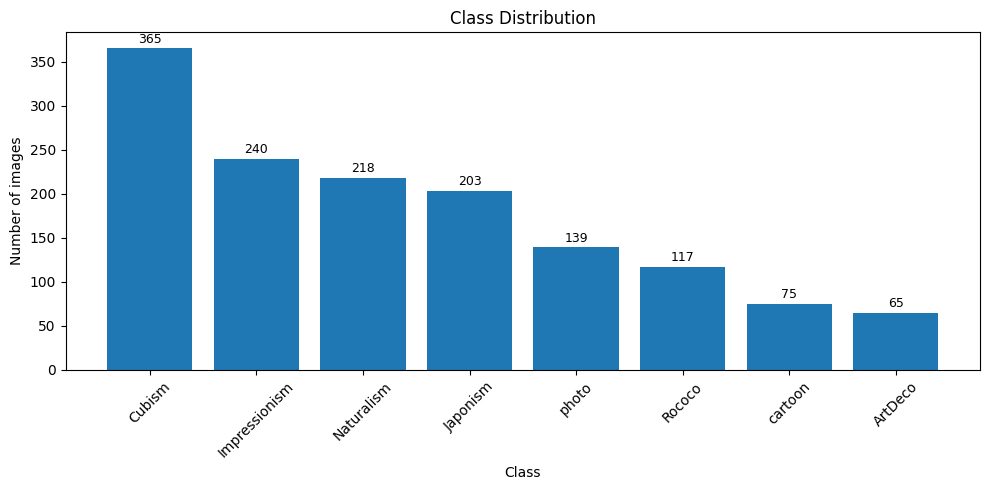

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\01_class_distribution.png
Saved class distribution table to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\class_distribution.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Build class distribution dataframe
class_count_records = []

for class_dir in class_dirs:
    n_images = sum(
        1
        for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )
    class_count_records.append({
        "class": class_dir.name,
        "count": n_images
    })

df_counts = pd.DataFrame(class_count_records)
df_counts = df_counts.sort_values("count", ascending=False).reset_index(drop=True)

total_images = df_counts["count"].sum()
num_classes = len(df_counts)
max_count = df_counts["count"].max()
min_count = df_counts["count"].min()
imbalance_ratio = max_count / min_count

df_counts["percentage"] = 100 * df_counts["count"] / total_images

print(f"Total images: {total_images}")
print(f"Number of classes: {num_classes}")
print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

display(df_counts)

# Save class distribution table
df_counts.to_csv(SPLITS_DIR / "class_distribution.csv", index=False)

# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df_counts["class"], df_counts["count"])
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=45)

for i, count in enumerate(df_counts["count"]):
    ax.text(i, count + 3, str(count), ha="center", va="bottom", fontsize=9)

fig.tight_layout()

fig_path = FIGURES_DIR / "01_class_distribution.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path}")
print(f"Saved class distribution table to: {SPLITS_DIR / 'class_distribution.csv'}")

## C. Visual Inspection

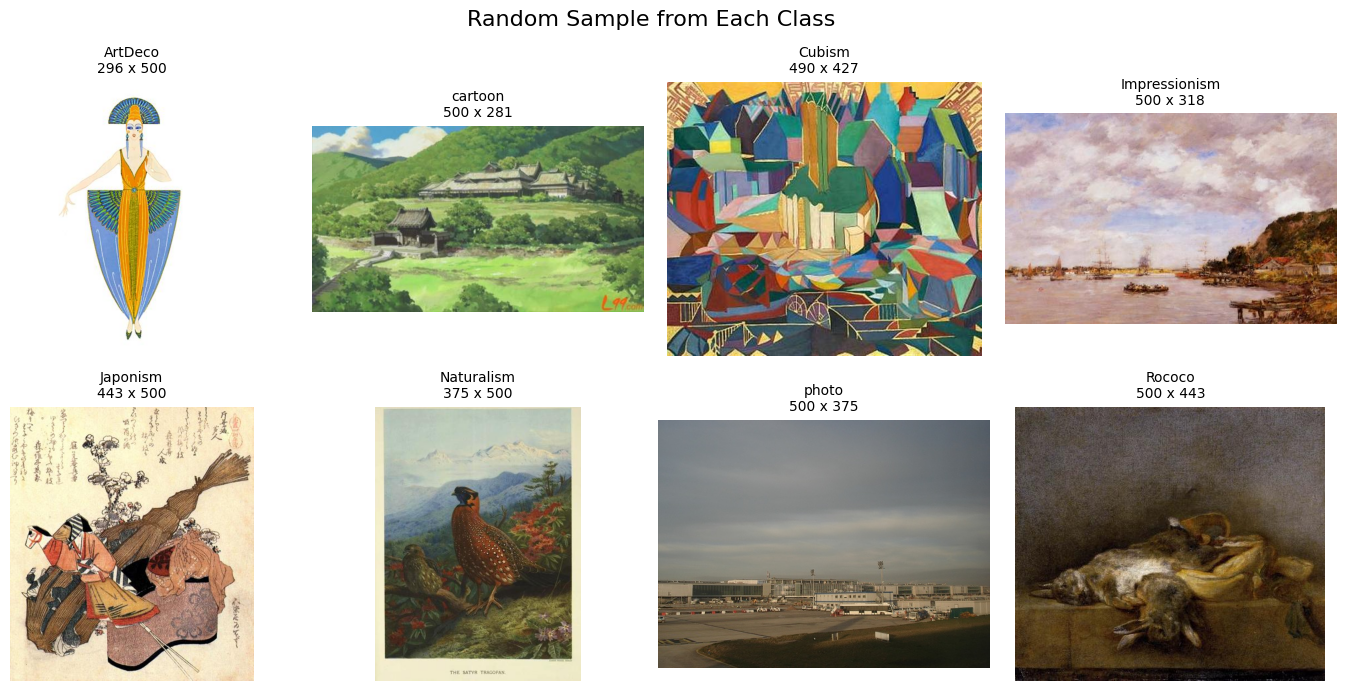

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\02_random_samples_per_class.png


In [4]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

rng = random.Random(SEED)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, class_dir in zip(axes, class_dirs):
    image_paths = sorted(
        [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
        ],
        key=lambda p: p.name.lower()
    )

    img_path = rng.choice(image_paths)

    with Image.open(img_path) as img:
        img = ImageOps.exif_transpose(img.convert("RGB"))
        width, height = img.size
        ax.imshow(img)

    ax.set_title(f"{class_dir.name}\n{width} x {height}", fontsize=10)
    ax.axis("off")

fig.suptitle("Random Sample from Each Class", fontsize=16)
fig.tight_layout()

fig_path = FIGURES_DIR / "02_random_samples_per_class.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path}")

### Initial EDA observations

The dataset contains 1422 images across 8 classes. The class distribution is imbalanced: Cubism is the largest class with 365 images, while ArtDeco is the smallest with 65 images. This means that plain accuracy may be misleading, because a model can perform well on large classes while failing on small classes.

For this reason, the main evaluation metrics should include macro-F1 and balanced accuracy, along with the confusion matrix and per-class precision/recall/F1.

The visual inspection also shows that the classes differ in texture, color, composition, and degree of realism. The `photo` class is visually different from the painting-style classes, so later model interpretation should check whether the model learns artistic style features or simply separates photographic texture from painted texture.

## D. Integrity and Dimension Scan

In [5]:
from PIL import Image, ImageOps
import pandas as pd

inventory_records = []
corrupted_records = []

for class_dir in sorted(class_dirs, key=lambda p: p.name.lower()):
    label = class_dir.name

    image_paths = sorted(
        [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
        ],
        key=lambda p: p.name.lower()
    )

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                img = ImageOps.exif_transpose(img.convert("RGB"))
                width, height = img.size

            aspect_ratio = width / height if height != 0 else None

            inventory_records.append({
                "source_path": img_path.relative_to(PROJECT_ROOT.parent).as_posix(),
                "filename": img_path.name,
                "label": label,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "suffix": img_path.suffix.lower(),
            })

        except Exception as e:
            corrupted_records.append({
                "source_path": img_path.relative_to(PROJECT_ROOT.parent).as_posix(),
                "filename": img_path.name,
                "label": label,
                "error": repr(e),
            })

df_inventory = pd.DataFrame(inventory_records)
df_corrupted = pd.DataFrame(
    corrupted_records,
    columns=["source_path", "filename", "label", "error"]
)

inventory_path = SPLITS_DIR / "image_inventory.csv"
corrupted_path = SPLITS_DIR / "corrupted_files.csv"

df_inventory.to_csv(inventory_path, index=False)
df_corrupted.to_csv(corrupted_path, index=False)

print(f"Readable images: {len(df_inventory)}")
print(f"Corrupted/unreadable images: {len(df_corrupted)}")
print(f"Saved inventory to: {inventory_path}")
print(f"Saved corrupted file report to: {corrupted_path}")

display(df_inventory.head())
display(df_inventory[["width", "height", "aspect_ratio"]].describe())

if len(df_corrupted) > 0:
    display(df_corrupted)

Readable images: 1422
Corrupted/unreadable images: 0
Saved inventory to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\image_inventory.csv
Saved corrupted file report to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\corrupted_files.csv


,source_path,filename,label,width,height,aspect_ratio,suffix
0,images/ArtDeco/aleksandra-ekster_woman-with-fi...,aleksandra-ekster_woman-with-fish-1934.jpg,ArtDeco,389,500,0.778,.jpg
1,images/ArtDeco/bernardo-marques_antonio-ferro-...,bernardo-marques_antonio-ferro-mundo-novo-capa...,ArtDeco,322,500,0.644,.jpg
2,images/ArtDeco/bernardo-marques_civiliza-o-no-...,bernardo-marques_civiliza-o-no-1-1928.jpg,ArtDeco,339,500,0.678,.jpg
3,images/ArtDeco/bernardo-marques_civiliza-o.jpg,bernardo-marques_civiliza-o.jpg,ArtDeco,343,500,0.686,.jpg
4,images/ArtDeco/bernardo-marques_fernanda-de-ca...,bernardo-marques_fernanda-de-castro-cidade-em-...,ArtDeco,336,500,0.672,.jpg


,width,height,aspect_ratio
count,1422.000000,1422.000000,1422.000000
mean,433.488045,424.085091,1.088167
std,79.794164,79.679216,0.383298
min,80.000000,82.000000,0.282000
25%,371.250000,367.250000,0.756000
50%,490.000000,422.000000,1.124872
75%,500.000000,500.000000,1.344086
max,500.000000,500.000000,3.571429


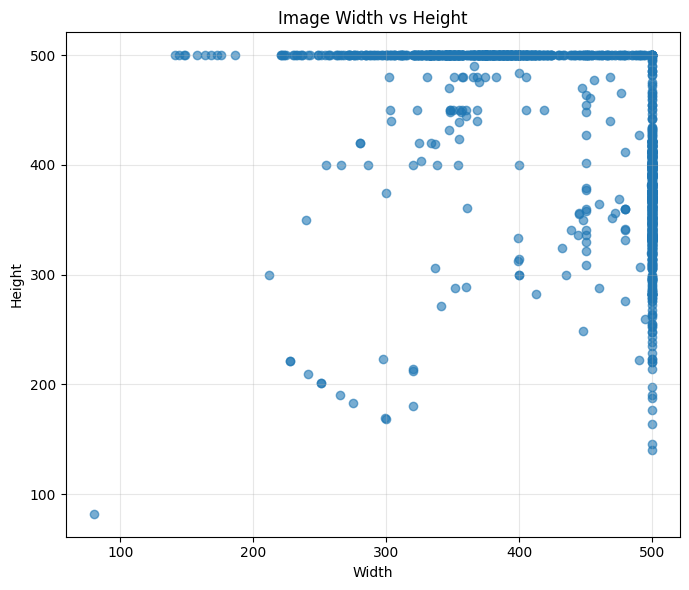

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\03_image_dimensions_scatter.png


In [6]:
# Width vs height scatter plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(df_inventory["width"], df_inventory["height"], alpha=0.6)
ax.set_title("Image Width vs Height")
ax.set_xlabel("Width")
ax.set_ylabel("Height")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIGURES_DIR / "03_image_dimensions_scatter.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path}")

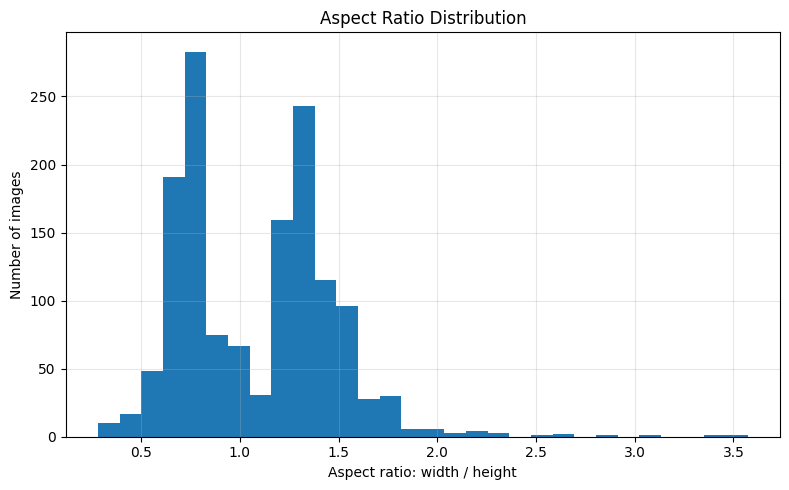

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\04_aspect_ratio_distribution.png


In [7]:
# Aspect-ratio distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_inventory["aspect_ratio"], bins=30)
ax.set_title("Aspect Ratio Distribution")
ax.set_xlabel("Aspect ratio: width / height")
ax.set_ylabel("Number of images")
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig_path = FIGURES_DIR / "04_aspect_ratio_distribution.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path}")

## E. Split Strategy

The dataset contains 1422 readable images and no corrupted images. Since the class distribution is imbalanced, the train/validation/test split should preserve the class proportions.

A stratified split is used:

- 70% training
- 15% validation
- 15% test

The split is saved in ImageFolder-compatible format under `data/processed/`, so later PyTorch can load it directly with `torchvision.datasets.ImageFolder`.

The split metadata is also saved to `data/splits/` for reproducibility.

## F. Stratified Split

In [8]:
from sklearn.model_selection import train_test_split
import shutil
import json

# ------------------------------------------------------------
# 1. Prepare dataframe for splitting
# ------------------------------------------------------------

df_split_source = df_inventory.copy().reset_index(drop=True)

print("Total readable images:", len(df_split_source))
print("Classes:")
display(df_split_source["label"].value_counts().sort_index())


# ------------------------------------------------------------
# 2. Create stratified 70 / 15 / 15 split
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df_split_source,
    test_size=0.30,
    stratify=df_split_source["label"],
    random_state=SEED,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Split sizes:")
print(df_manifest["split"].value_counts())

Total readable images: 1422
Classes:


label
ArtDeco           65
Cubism           365
Impressionism    240
Japonism         203
Naturalism       218
Rococo           117
cartoon           75
photo            139
Name: count, dtype: int64

Split sizes:
split
train    995
test     214
val      213
Name: count, dtype: int64


In [9]:
# ------------------------------------------------------------
# 3. Clear previous processed split folders
# ------------------------------------------------------------

for split_name in ["train", "val", "test"]:
    split_dir = PROCESSED_DIR / split_name

    if split_dir.exists():
        shutil.rmtree(split_dir)

    split_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 4. Copy files into ImageFolder-compatible structure
# ------------------------------------------------------------

processed_paths = []

for _, row in df_manifest.iterrows():
    split_name = row["split"]
    label = row["label"]
    filename = row["filename"]

    # source_path is relative to Task_IML_2_data, e.g. images/Cubism/example.jpg
    src_path = PROJECT_ROOT.parent / row["source_path"]

    dst_dir = PROCESSED_DIR / split_name / label
    dst_dir.mkdir(parents=True, exist_ok=True)

    dst_path = dst_dir / filename

    shutil.copy2(src_path, dst_path)

    # Save processed path relative to PROJECT_ROOT, not absolute Windows path
    processed_paths.append(dst_path.relative_to(PROJECT_ROOT).as_posix())

df_manifest["processed_path"] = processed_paths

print("Finished copying images.")
print("Processed directory:", PROCESSED_DIR)

Finished copying images.
Processed directory: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\processed


In [10]:
# ------------------------------------------------------------
# 5. Save split metadata
# ------------------------------------------------------------

# Keep useful columns in clear order
manifest_cols = [
    "source_path",
    "processed_path",
    "filename",
    "label",
    "split",
    "width",
    "height",
    "aspect_ratio",
    "suffix",
]

df_manifest = df_manifest[manifest_cols].sort_values(
    ["split", "label", "filename"]
).reset_index(drop=True)

manifest_path = SPLITS_DIR / "split_manifest.csv"
df_manifest.to_csv(manifest_path, index=False)

print(f"Saved split manifest to: {manifest_path}")


# ------------------------------------------------------------
# 6. Save split crosstab counts
# ------------------------------------------------------------

split_crosstab_counts = pd.crosstab(
    df_manifest["label"],
    df_manifest["split"],
    margins=True
)

crosstab_counts_path = SPLITS_DIR / "split_crosstab.csv"
split_crosstab_counts.to_csv(crosstab_counts_path)

print(f"Saved split crosstab counts to: {crosstab_counts_path}")
display(split_crosstab_counts)


# ------------------------------------------------------------
# 7. Save split crosstab percentages per class
# ------------------------------------------------------------

split_counts_no_margin = pd.crosstab(
    df_manifest["label"],
    df_manifest["split"]
)

split_crosstab_percentages = split_counts_no_margin.div(
    split_counts_no_margin.sum(axis=1),
    axis=0
) * 100

percentages_path = SPLITS_DIR / "split_crosstab_percentages.csv"
split_crosstab_percentages.to_csv(percentages_path)

print(f"Saved split crosstab percentages to: {percentages_path}")
display(split_crosstab_percentages.round(2))


# ------------------------------------------------------------
# 8. Save class mappings
# ------------------------------------------------------------

class_names = sorted(df_manifest["label"].unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

class_to_idx_path = SPLITS_DIR / "class_to_idx.json"
idx_to_class_path = SPLITS_DIR / "idx_to_class.json"

with open(class_to_idx_path, "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, indent=4)

with open(idx_to_class_path, "w", encoding="utf-8") as f:
    json.dump(idx_to_class, f, indent=4)

print(f"Saved class_to_idx to: {class_to_idx_path}")
print(f"Saved idx_to_class to: {idx_to_class_path}")

print("Class mapping:")
class_to_idx

Saved split manifest to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\split_manifest.csv
Saved split crosstab counts to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\split_crosstab.csv


split,test,train,val,All
label,,,,
ArtDeco,9,46,10,65
Cubism,55,255,55,365
Impressionism,36,168,36,240
Japonism,31,142,30,203
Naturalism,33,153,32,218
Rococo,18,82,17,117
cartoon,11,52,12,75
photo,21,97,21,139
All,214,995,213,1422


Saved split crosstab percentages to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\split_crosstab_percentages.csv


split,test,train,val
label,,,
ArtDeco,13.85,70.77,15.38
Cubism,15.07,69.86,15.07
Impressionism,15.00,70.00,15.00
Japonism,15.27,69.95,14.78
Naturalism,15.14,70.18,14.68
Rococo,15.38,70.09,14.53
cartoon,14.67,69.33,16.00
photo,15.11,69.78,15.11


Saved class_to_idx to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\class_to_idx.json
Saved idx_to_class to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\data\splits\idx_to_class.json
Class mapping:


{'ArtDeco': 0,
 'Cubism': 1,
 'Impressionism': 2,
 'Japonism': 3,
 'Naturalism': 4,
 'Rococo': 5,
 'cartoon': 6,
 'photo': 7}

In [11]:
# ------------------------------------------------------------
# 9. Verify processed split
# ------------------------------------------------------------

verification_records = []

for split_name in ["train", "val", "test"]:
    split_dir = PROCESSED_DIR / split_name

    for class_name in class_names:
        class_dir = split_dir / class_name

        n_files = 0
        if class_dir.exists():
            n_files = sum(
                1
                for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
            )

        verification_records.append({
            "split": split_name,
            "class": class_name,
            "count": n_files,
        })

df_verification = pd.DataFrame(verification_records)

verification_table = df_verification.pivot(
    index="class",
    columns="split",
    values="count"
)

verification_table["total"] = verification_table.sum(axis=1)

display(verification_table)

print("Total copied files:", verification_table["total"].sum())
print("Expected readable images:", len(df_inventory))

assert verification_table["total"].sum() == len(df_inventory), (
    "Mismatch between copied files and readable image inventory."
)

print("Verification passed.")

split,test,train,val,total
class,,,,
ArtDeco,9,46,10,65
Cubism,55,255,55,365
Impressionism,36,168,36,240
Japonism,31,142,30,203
Naturalism,33,153,32,218
Rococo,18,82,17,117
cartoon,11,52,12,75
photo,21,97,21,139


Total copied files: 1422
Expected readable images: 1422
Verification passed.


Original size: (389, 500)
Padded size: (500, 500)


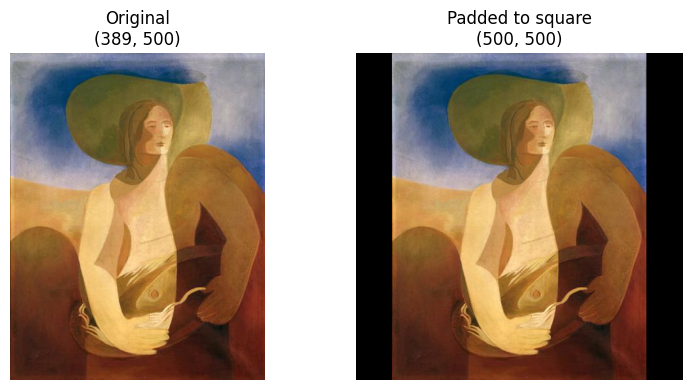

In [18]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt


class PadToSquare:
    """
    Pad a PIL image to a square shape while preserving the original aspect ratio.

    This avoids distorting images before resizing them to 128x128.
    """

    def __init__(self, fill=(0, 0, 0)):
        self.fill = fill

    def __call__(self, img):
        width, height = img.size
        max_side = max(width, height)

        pad_left = (max_side - width) // 2
        pad_top = (max_side - height) // 2
        pad_right = max_side - width - pad_left
        pad_bottom = max_side - height - pad_top

        padded_img = ImageOps.expand(
            img,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill=self.fill,
        )

        return padded_img


# Quick test on one image
if not df_inventory.empty:
    sample_path = PROJECT_ROOT.parent / df_inventory.iloc[0]["source_path"]

    with Image.open(sample_path) as img:
        img = ImageOps.exif_transpose(img.convert("RGB"))
        padded_img = PadToSquare(fill=(0, 0, 0))(img)

    print("Original size:", img.size)
    print("Padded size:", padded_img.size)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"Original\n{img.size}")
    axes[0].axis("off")

    axes[1].imshow(padded_img)
    axes[1].set_title(f"Padded to square\n{padded_img.size}")
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

## Preprocessing Decision

Because the dataset contains images with mixed aspect ratios, the training pipeline should avoid directly stretching images to a square. Direct resizing can distort composition and style-related features.

The planned preprocessing is:

Training:

`PadToSquare → Resize(128, 128) → RandomHorizontalFlip → RandomRotation(10) → ColorJitter → ToTensor`

Validation/test:

`PadToSquare → Resize(128, 128) → ToTensor`

The target size is 128x128 because style classification depends on texture, color, and composition, and 128x128 preserves more visual detail than 64x64 while still being lightweight enough for training in Colab.